# Персонализированная система развивающих заданий для детей дошкольного возраста
## Использование машинного обучения для кластеризации и генерации заданий

**Направление:** Применение методов машинного обучения в образовании  
**Дата:** Март 2026

---

### Аннотация

Данная работа представляет **систему персонализации образовательного процесса** для детей
дошкольного возраста (3–7 лет) с использованием методов машинного обучения.

На основе данных тестирования **300 детей** по **50 заданиям** пяти
когнитивных категорий выполнена кластеризация по уровням развития.
Для каждой из четырёх выделенных групп разработан генератор персонализированных
развивающих заданий (20 заданий на ребёнка).

---

### Содержание

| № | Раздел |
|---|--------|
| 1 | Загрузка данных тестирования |
| 2 | Разведочный анализ данных (EDA) |
| 3 | Предобработка и инженерия признаков |
| 4 | Выбор числа кластеров: метод локтя + силуэт |
| 5 | K-Means кластеризация |
| 6 | Визуализация кластеров (PCA + t-SNE) |
| 7 | Интерпретация и профилирование кластеров |
| 8 | Генератор персонализированных развивающих заданий |
| 9 | Демонстрация системы на конкретных детях |
| 10 | Оценка качества модели |
| 11 | Выводы и заключение |


In [1]:
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              confusion_matrix)
from scipy.spatial.distance import cdist

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

CLUSTER_COLORS = ['#e17055', '#fdcb6e', '#00b894', '#6c5ce7']
CLUSTER_NAMES  = {
    0: 'А – Требует поддержки',
    1: 'Б – Средний',
    2: 'В – Уверенный',
    3: 'Г – Продвинутый',
}
CLUSTER_SHORT = {k: v.split('–')[0].strip() for k, v in CLUSTER_NAMES.items()}


---
## 1. Загрузка данных тестирования

### Структура теста

Тест содержит **50 заданий** в пяти категориях по 10 заданий каждая:

| Категория | Задания | Тип ответа | Пример задания |
|-----------|---------|-----------|----------------|
| Формы | 1–10 | Бинарный (0/1) | «Покажи треугольник», «Нарисуй круг» |
| Цвета | 11–20 | Бинарный (0/1) | «Какого цвета небо?», «Найди красный предмет» |
| Счёт | 21–30 | Балл 0–3 | «Сколько звёздочек?», «Посчитай кубики» |
| Память | 31–40 | Бинарный (0/1) | «Запомни 3 предмета», «Повтори последовательность» |
| Логика | 41–50 | Бинарный (0/1) | «Что лишнее?», «Продолжи ряд» |

**Выборка:** 300 детей, возраст 3–7 лет.


In [2]:
# ─── Описание всех 50 заданий ─────────────────────────────────────────────────

meta_df = pd.read_excel('question_meta.xlsx', index_col='Задание')
QUESTION_META = meta_df['Описание задания'].to_dict()

print(f"Загружено {len(QUESTION_META)} заданий.")
meta_df


Загружено 50 заданий.


,Описание задания
Задание,
Форма_1,Покажи на картинке круг
Форма_2,Покажи на картинке треугольник
Форма_3,Покажи на картинке квадрат
Форма_4,Обведи все прямоугольники на рисунке
Форма_5,Назови форму предмета (мяч)
Форма_6,Назови форму предмета (книга)
Форма_7,Сколько углов у треугольника?
Форма_8,Найди одинаковые фигуры среди 6 предложенных
Форма_9,Собери фигуру из частей (пазл)


In [3]:
# ─── Загрузка данных ─────────────────────────────────────────────────────────

df_raw = pd.read_excel('children_data.xlsx')

q_cols = [c for c in df_raw.columns if c not in ['ID', 'Возраст', 'Пол']]
N_CHILDREN  = len(df_raw)
N_QUESTIONS = len(q_cols)

print(f"Датасет: {df_raw.shape[0]} детей x {df_raw.shape[1]} столбцов")
print(f"Вопросы: {N_QUESTIONS} заданий по категориям Формы, Цвета, Счёт, Память, Логика")
print("\nПример записей:")
display(df_raw.head(6))


Датасет: 300 детей x 53 столбцов
Вопросы: 50 заданий по категориям Формы, Цвета, Счёт, Память, Логика

Пример записей:


,ID,Возраст,Пол,Форма_1,Форма_2,Форма_3,Форма_4,Форма_5,Форма_6,Форма_7,...,Логика_1,Логика_2,Логика_3,Логика_4,Логика_5,Логика_6,Логика_7,Логика_8,Логика_9,Логика_10
0,CHILD_0001,5,М,1,0,1,0,1,0,1,...,1,0,0,0,0,1,0,0,1,1
1,CHILD_0002,7,Ж,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
2,CHILD_0003,6,Ж,1,1,1,1,1,1,1,...,1,1,1,0,1,1,1,1,1,1
3,CHILD_0004,5,Ж,0,0,1,1,0,1,1,...,0,0,1,0,1,1,0,0,1,1
4,CHILD_0005,4,М,0,0,0,1,0,0,1,...,0,0,1,0,0,1,0,0,1,1
5,CHILD_0006,4,М,0,0,1,1,1,0,1,...,1,0,1,0,0,1,0,1,0,0


In [4]:
# ─── Основная информация о датасете ──────────────────────────────────────────
print("=== Базовая статистика ===")
print(df_raw[q_cols].describe().round(2).to_string())
print()
print("=== Распределение по возрасту ===")
print(df_raw['Возраст'].value_counts().sort_index().to_string())
print()
print("=== Распределение по полу ===")
print(df_raw['Пол'].value_counts().to_string())


=== Базовая статистика ===
       Форма_1  Форма_2  Форма_3  Форма_4  Форма_5  Форма_6  Форма_7  Форма_8  Форма_9  Форма_10  Цвет_1  Цвет_2  Цвет_3  Цвет_4  Цвет_5  Цвет_6  Цвет_7  Цвет_8  Цвет_9  Цвет_10  Счёт_1  Счёт_2  Счёт_3  Счёт_4  Счёт_5  Счёт_6  Счёт_7  Счёт_8  Счёт_9  Счёт_10  Память_1  Память_2  Память_3  Память_4  Память_5  Память_6  Память_7  Память_8  Память_9  Память_10  Логика_1  Логика_2  Логика_3  Логика_4  Логика_5  Логика_6  Логика_7  Логика_8  Логика_9  Логика_10
count   300.00   300.00   300.00   300.00   300.00   300.00   300.00   300.00   300.00    300.00  300.00  300.00  300.00  300.00  300.00  300.00  300.00  300.00  300.00   300.00  300.00  300.00  300.00  300.00  300.00  300.00  300.00  300.00  300.00   300.00    300.00    300.00    300.00    300.00    300.00    300.00    300.00    300.00    300.00     300.00    300.00    300.00    300.00    300.00    300.00    300.00    300.00    300.00    300.00     300.00
mean      0.60     0.59     0.61     0.57     0.58 

---
## 2. Разведочный анализ данных (EDA)

Изучим демографику, распределения баллов по категориям и взаимосвязи признаков.


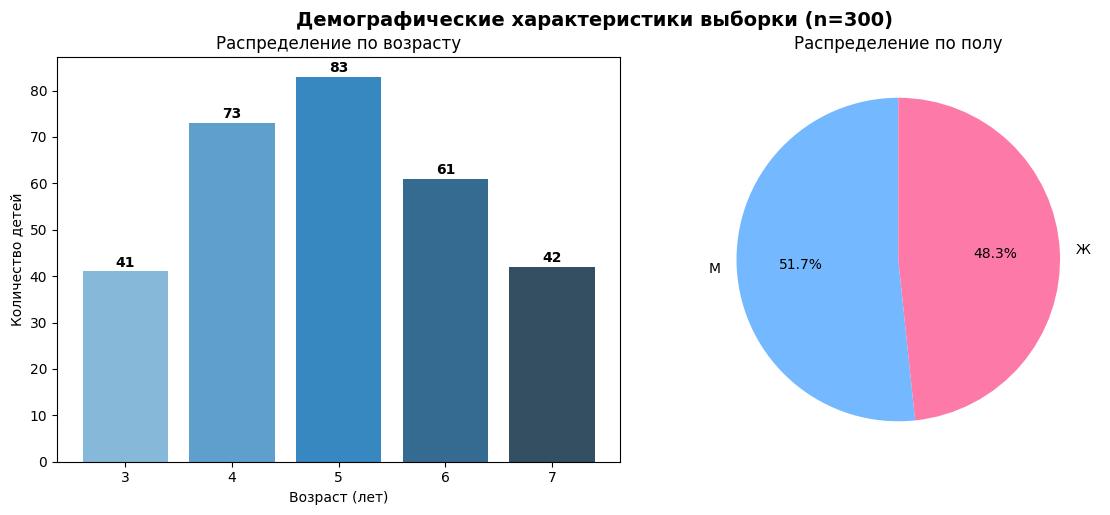

In [5]:
# ─── Демографика ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_cnt = df_raw['Возраст'].value_counts().sort_index()
axes[0].bar(age_cnt.index, age_cnt.values,
            color=sns.color_palette('Blues_d', len(age_cnt)))
axes[0].set_title('Распределение по возрасту')
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Количество детей')
for x, y in zip(age_cnt.index, age_cnt.values):
    axes[0].text(x, y + 1, str(y), ha='center', fontweight='bold')

gender_cnt = df_raw['Пол'].value_counts()
axes[1].pie(gender_cnt.values, labels=gender_cnt.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#74b9ff', '#fd79a8'])
axes[1].set_title('Распределение по полу')

plt.tight_layout()
plt.suptitle('Демографические характеристики выборки (n=300)', y=1.02, fontsize=14, fontweight='bold')
plt.show()


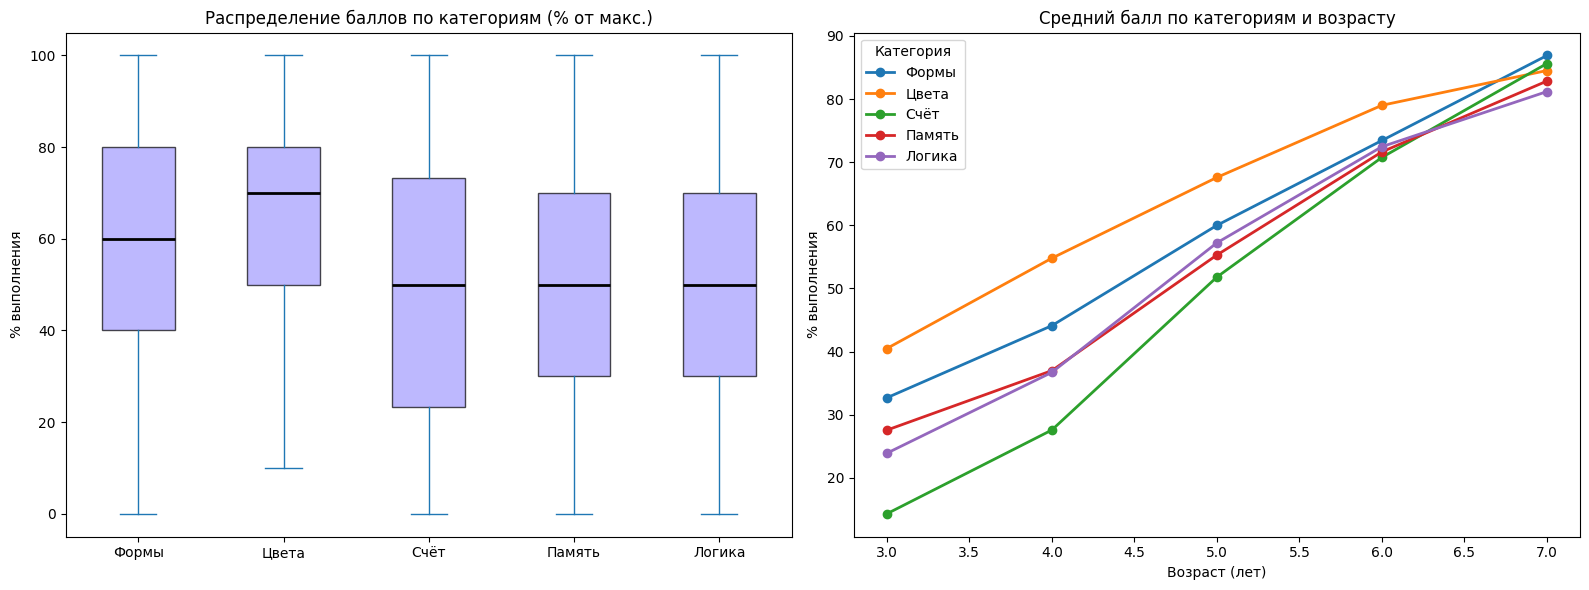

In [6]:
# ─── Агрегированные баллы по категориям ──────────────────────────────────────
categories = {
    'Формы':   [f'Форма_{i}'  for i in range(1, 11)],
    'Цвета':   [f'Цвет_{i}'   for i in range(1, 11)],
    'Счёт':    [f'Счёт_{i}'   for i in range(1, 11)],
    'Память':  [f'Память_{i}' for i in range(1, 11)],
    'Логика':  [f'Логика_{i}' for i in range(1, 11)],
}

for cat, cols in categories.items():
    max_score = 30 if cat == 'Счёт' else 10
    df_raw[f'Балл_{cat}'] = df_raw[cols].sum(axis=1) / max_score * 100

score_cols = [f'Балл_{c}' for c in categories]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_raw[score_cols].rename(columns={c: c.replace('Балл_', '') for c in score_cols}).plot(
    kind='box', ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='#a29bfe', alpha=0.7),
    medianprops=dict(color='black', linewidth=2)
)
axes[0].set_title('Распределение баллов по категориям (% от макс.)')
axes[0].set_ylabel('% выполнения')
axes[0].set_xticklabels(['Формы', 'Цвета', 'Счёт', 'Память', 'Логика'])

age_means = df_raw.groupby('Возраст')[score_cols].mean()
for i, col in enumerate(score_cols):
    axes[1].plot(age_means.index, age_means[col],
                 marker='o', label=col.replace('Балл_', ''), linewidth=2)
axes[1].set_title('Средний балл по категориям и возрасту')
axes[1].set_xlabel('Возраст (лет)')
axes[1].set_ylabel('% выполнения')
axes[1].legend(title='Категория')

plt.tight_layout()
plt.show()


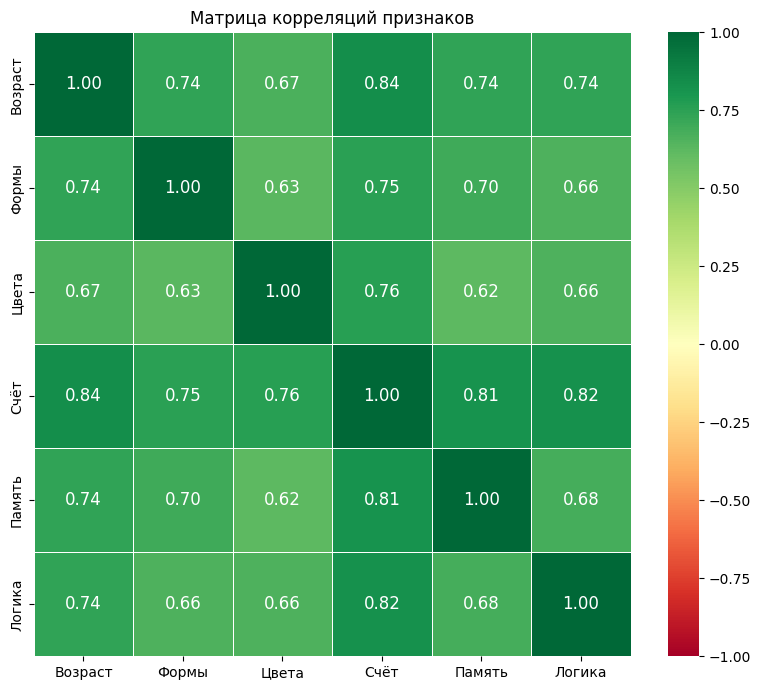


Топ-3 сильные корреляции:
Счёт     Возраст    0.840645
Возраст  Счёт       0.840645
Логика   Счёт       0.822231
Счёт     Логика     0.822231
Память   Счёт       0.813567
Счёт     Память     0.813567


In [7]:
# ─── Матрица корреляций (агрегированные баллы) ───────────────────────────────
corr_data = df_raw[['Возраст'] + score_cols].copy()
corr_data.columns = ['Возраст', 'Формы', 'Цвета', 'Счёт', 'Память', 'Логика']

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, mask=False,
            annot_kws={'size': 12}, vmin=-1, vmax=1)
ax.set_title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

max_corr = corr_data.corr().abs().unstack()
max_corr = max_corr[max_corr < 1].sort_values(ascending=False)
print("\nТоп-3 сильные корреляции:")
print(max_corr.head(6).to_string())


---
## 3. Предобработка и инженерия признаков

Для кластеризации используем **агрегированные баллы** по 5 категориям
(нормированные 0–100%) и возраст. Применяем **StandardScaler** для приведения
признаков к единому масштабу.


In [8]:
# ─── Предобработка ────────────────────────────────────────────────────────────
feature_cols = ['Возраст'] + score_cols
X_raw = df_raw[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Признаки для кластеризации:", feature_cols)
print(f"Матрица признаков: {X_scaled.shape}")
print()

feature_df = pd.DataFrame(X_raw, columns=['Возраст','Формы','Цвета','Счёт','Память','Логика'])
print("Статистика признаков (до нормировки):")
display(feature_df.describe().round(2))


Признаки для кластеризации: ['Возраст', 'Балл_Формы', 'Балл_Цвета', 'Балл_Счёт', 'Балл_Память', 'Балл_Логика']
Матрица признаков: (300, 6)

Статистика признаков (до нормировки):


,Возраст,Формы,Цвета,Счёт,Память,Логика
count,300.00,300.00,300.00,300.00,300.00,300.00
mean,4.97,58.90,65.47,49.38,54.23,54.13
std,1.25,23.59,21.01,28.11,25.16,25.97
min,3.00,0.00,10.00,0.00,0.00,0.00
25%,4.00,40.00,50.00,23.33,30.00,30.00
50%,5.00,60.00,70.00,50.00,50.00,50.00
75%,6.00,80.00,80.00,73.33,70.00,70.00
max,7.00,100.00,100.00,100.00,100.00,100.00


---
## 4. Выбор числа кластеров

Используем два критерия:
- **Метод локтя (Elbow)** — минимизация суммы квадратов расстояний (WCSS / Inertia)
- **Коэффициент силуэта (Silhouette Score)** — оценка плотности и разделённости кластеров


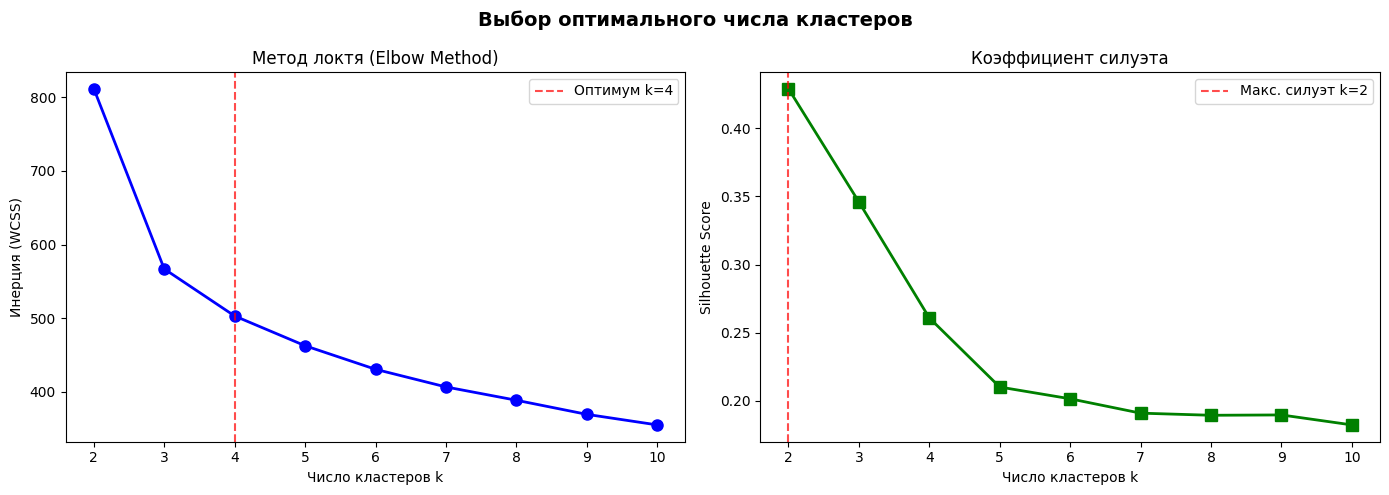

Лучший силуэт: k=2, score=0.4290
Вывод: выбираем k=4 (соответствует 4 уровням развития)


In [9]:
# ─── Метод локтя + силуэтный анализ ──────────────────────────────────────────
K_range = range(2, 11)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Оптимум k=4')
axes[0].set_title('Метод локтя (Elbow Method)')
axes[0].set_xlabel('Число кластеров k')
axes[0].set_ylabel('Инерция (WCSS)')
axes[0].legend()

best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].plot(list(K_range), sil_scores, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
                label=f'Макс. силуэт k={best_k}')
axes[1].set_title('Коэффициент силуэта')
axes[1].set_xlabel('Число кластеров k')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Выбор оптимального числа кластеров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Лучший силуэт: k={best_k}, score={max(sil_scores):.4f}")
print("Вывод: выбираем k=4 (соответствует 4 уровням развития)")


In [10]:
# ─── K-Means кластеризация (k=4) ─────────────────────────────────────────────
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=50,
                max_iter=500, random_state=42)
cluster_labels_raw = kmeans.fit_predict(X_scaled)

# Переупорядочим кластеры по среднему общему баллу (от низкого к высокому)
cluster_means = pd.DataFrame(X_raw, columns=['Возраст','Формы','Цвета','Счёт','Память','Логика'])
cluster_means['_cluster'] = cluster_labels_raw
order = cluster_means.groupby('_cluster')['Формы'].mean().sort_values().index.tolist()
remap = {old: new for new, old in enumerate(order)}
cluster_labels = np.array([remap[c] for c in cluster_labels_raw])

df_raw['Кластер'] = cluster_labels
df_raw['Уровень'] = df_raw['Кластер'].map(CLUSTER_NAMES)
df_raw['Уровень_кратко'] = df_raw['Кластер'].map(CLUSTER_SHORT)

sil = silhouette_score(X_scaled, cluster_labels)
print(f"K-Means k=4  |  Silhouette Score: {sil:.4f}")
print()
print("Распределение по кластерам:")
for k in range(OPTIMAL_K):
    n = (cluster_labels == k).sum()
    print(f"  {CLUSTER_NAMES[k]}: {n} детей ({n/N_CHILDREN*100:.1f}%)")


K-Means k=4  |  Silhouette Score: 0.2608

Распределение по кластерам:
  А – Требует поддержки: 65 детей (21.7%)
  Б – Средний: 56 детей (18.7%)
  В – Уверенный: 99 детей (33.0%)
  Г – Продвинутый: 80 детей (26.7%)


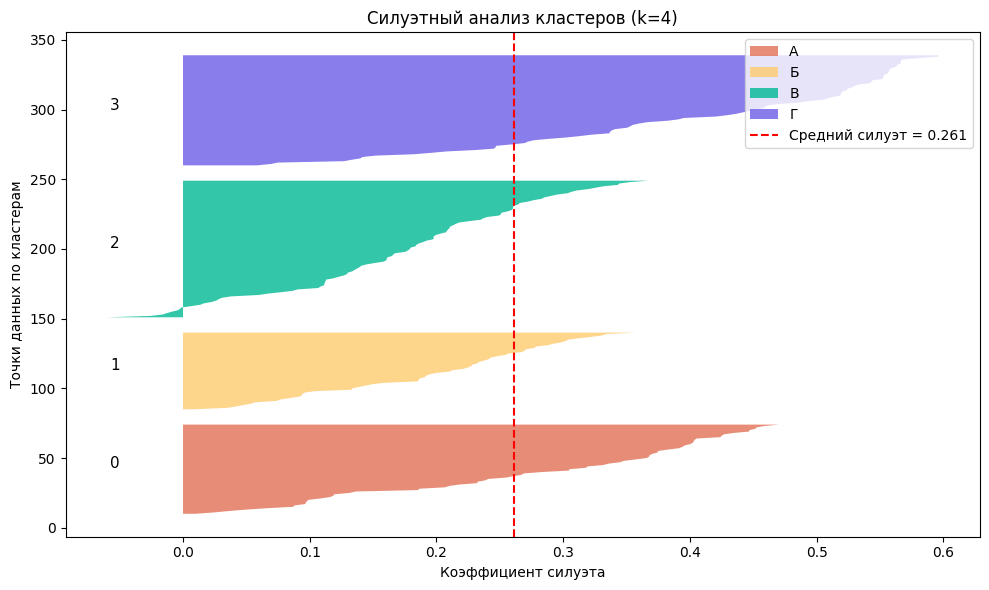

Средний коэффициент силуэта: 0.2608


In [11]:
# ─── Силуэтный график ────────────────────────────────────────────────────────
sil_vals = silhouette_samples(X_scaled, cluster_labels)
avg_sil  = silhouette_score(X_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for k in range(OPTIMAL_K):
    k_sil = np.sort(sil_vals[cluster_labels == k])
    size  = k_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, k_sil,
                     facecolor=CLUSTER_COLORS[k], alpha=0.8,
                     label=CLUSTER_SHORT[k])
    ax.text(-0.05, y_lower + 0.5 * size, str(k), ha='right', fontsize=11)
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Средний силуэт = {avg_sil:.3f}')
ax.set_title('Силуэтный анализ кластеров (k=4)')
ax.set_xlabel('Коэффициент силуэта')
ax.set_ylabel('Точки данных по кластерам')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(f"Средний коэффициент силуэта: {avg_sil:.4f}")


---
## 5. Визуализация кластеров (PCA + t-SNE)

Для наглядного отображения многомерных данных используем:
- **PCA** (Principal Component Analysis) — линейное снижение размерности
- **t-SNE** — нелинейное снижение для обнаружения нелинейных структур


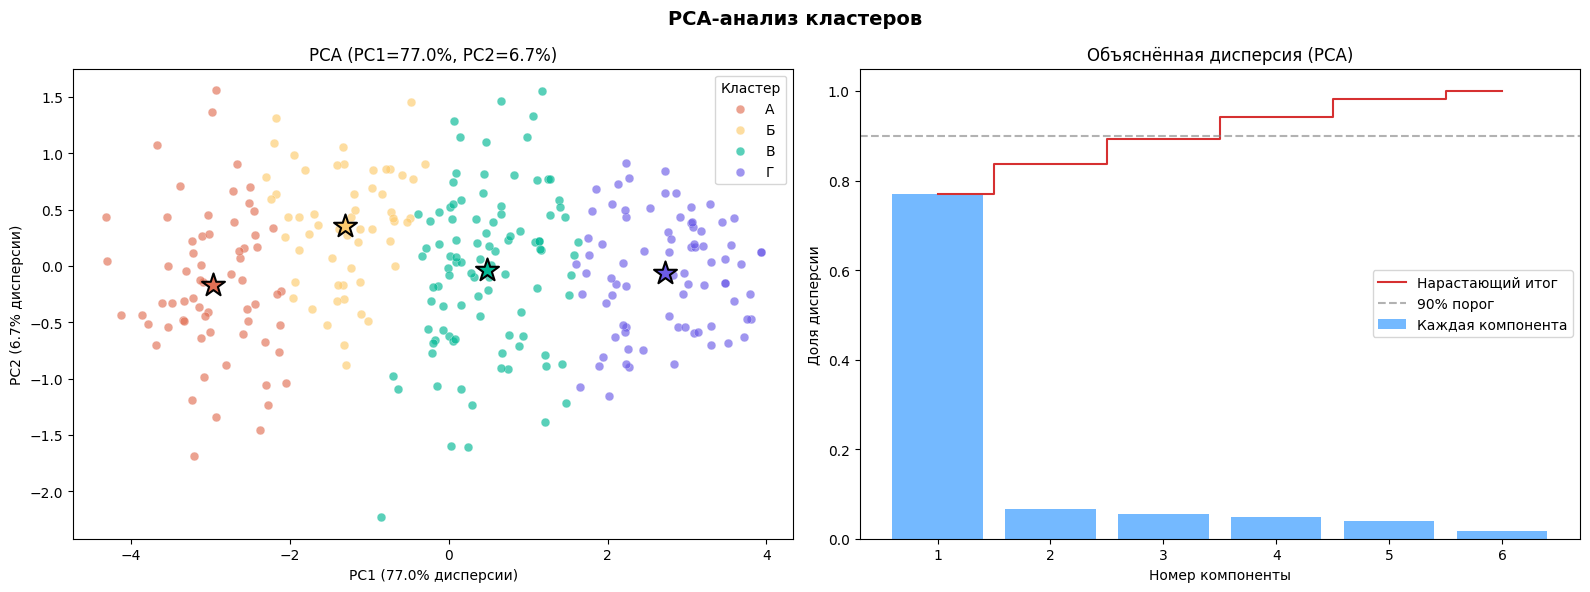

Первые 2 PC объясняют 83.7% дисперсии.


In [12]:
# ─── PCA — снижение до 2 компонент ──────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for k in range(OPTIMAL_K):
    mask = cluster_labels == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=CLUSTER_COLORS[k], label=CLUSTER_SHORT[k],
                    alpha=0.65, s=40, edgecolors='white', linewidths=0.3)
centroids_pca = pca.transform(kmeans.cluster_centers_[[remap[c] for c in range(OPTIMAL_K)]])
for k in range(OPTIMAL_K):
    axes[0].scatter(*centroids_pca[k], c=CLUSTER_COLORS[k],
                    marker='*', s=300, edgecolors='black', linewidths=1.5, zorder=5)
axes[0].set_title(f'PCA (PC1={exp_var[0]:.1%}, PC2={exp_var[1]:.1%})')
axes[0].set_xlabel(f'PC1 ({exp_var[0]:.1%} дисперсии)')
axes[0].set_ylabel(f'PC2 ({exp_var[1]:.1%} дисперсии)')
axes[0].legend(title='Кластер')

pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_,
            color='#74b9ff', label='Каждая компонента')
axes[1].step(range(1, len(cumvar)+1), cumvar, where='mid',
             color='#d63031', label='Нарастающий итог')
axes[1].axhline(0.90, linestyle='--', color='gray', alpha=0.6, label='90% порог')
axes[1].set_title('Объяснённая дисперсия (PCA)')
axes[1].set_xlabel('Номер компоненты')
axes[1].set_ylabel('Доля дисперсии')
axes[1].legend()

plt.suptitle('PCA-анализ кластеров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Первые 2 PC объясняют {sum(exp_var)*100:.1f}% дисперсии.")


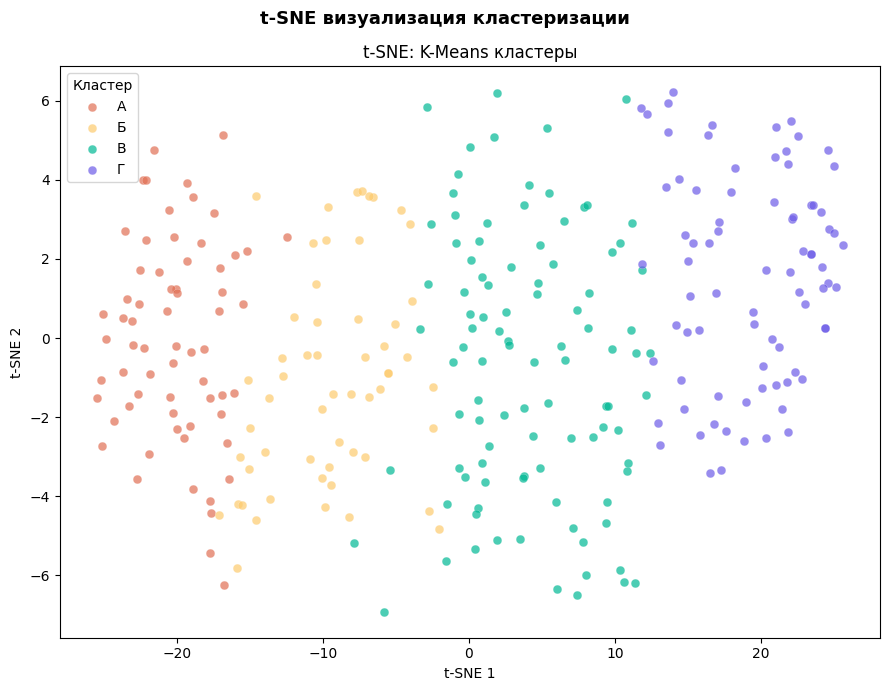

In [13]:
# ─── t-SNE ────────────────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for k in range(OPTIMAL_K):
    mask = cluster_labels == k
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=CLUSTER_COLORS[k], label=CLUSTER_SHORT[k],
               alpha=0.7, s=40, edgecolors='white', linewidths=0.2)
ax.set_title('t-SNE: K-Means кластеры')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(title='Кластер')
plt.suptitle('t-SNE визуализация кластеризации', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Интерпретация и профилирование кластеров

Анализируем каждый кластер по средним значениям признаков,
строим радарную диаграмму профилей и сравниваем с истинными уровнями.


In [14]:
# ─── Профили кластеров — таблица ─────────────────────────────────────────────
profile_cols = ['Возраст', 'Балл_Формы', 'Балл_Цвета', 'Балл_Счёт', 'Балл_Память', 'Балл_Логика']
profile = df_raw.groupby('Кластер')[profile_cols].mean().round(1)
profile.index = [CLUSTER_NAMES[k] for k in profile.index]
profile.columns = ['Возраст (лет)', 'Формы (%)', 'Цвета (%)', 'Счёт (%)', 'Память (%)', 'Логика (%)']

print("=== Профили кластеров ===")
display(profile)

# Размер кластеров
sizes = df_raw['Кластер'].value_counts().sort_index()
sizes.index = [CLUSTER_NAMES[k] for k in sizes.index]
print("\n=== Размер кластеров ===")
display(sizes.rename('Количество детей'))


=== Профили кластеров ===


,Возраст (лет),Формы (%),Цвета (%),Счёт (%),Память (%),Логика (%)
А – Требует поддержки,3.5,31.7,38.6,13.3,26.5,22.0
Б – Средний,4.2,46.1,62.0,30.6,37.0,41.2
В – Уверенный,5.2,63.2,68.0,55.6,58.7,60.9
Г – Продвинутый,6.4,84.6,86.6,84.1,83.4,80.9



=== Размер кластеров ===


А – Требует поддержки    65
Б – Средний              56
В – Уверенный            99
Г – Продвинутый          80
Name: Количество детей, dtype: int64

In [15]:
# ─── Профили кластеров ────────────────────────────────────────────────────────
profile_vals = df_raw.groupby('Кластер')[score_cols].mean()
print(profile_vals.round(1).to_string())


         Балл_Формы  Балл_Цвета  Балл_Счёт  Балл_Память  Балл_Логика
Кластер                                                             
0              31.7        38.6       13.3         26.5         22.0
1              46.1        62.0       30.6         37.0         41.2
2              63.2        68.0       55.6         58.7         60.9
3              84.6        86.6       84.1         83.4         80.9


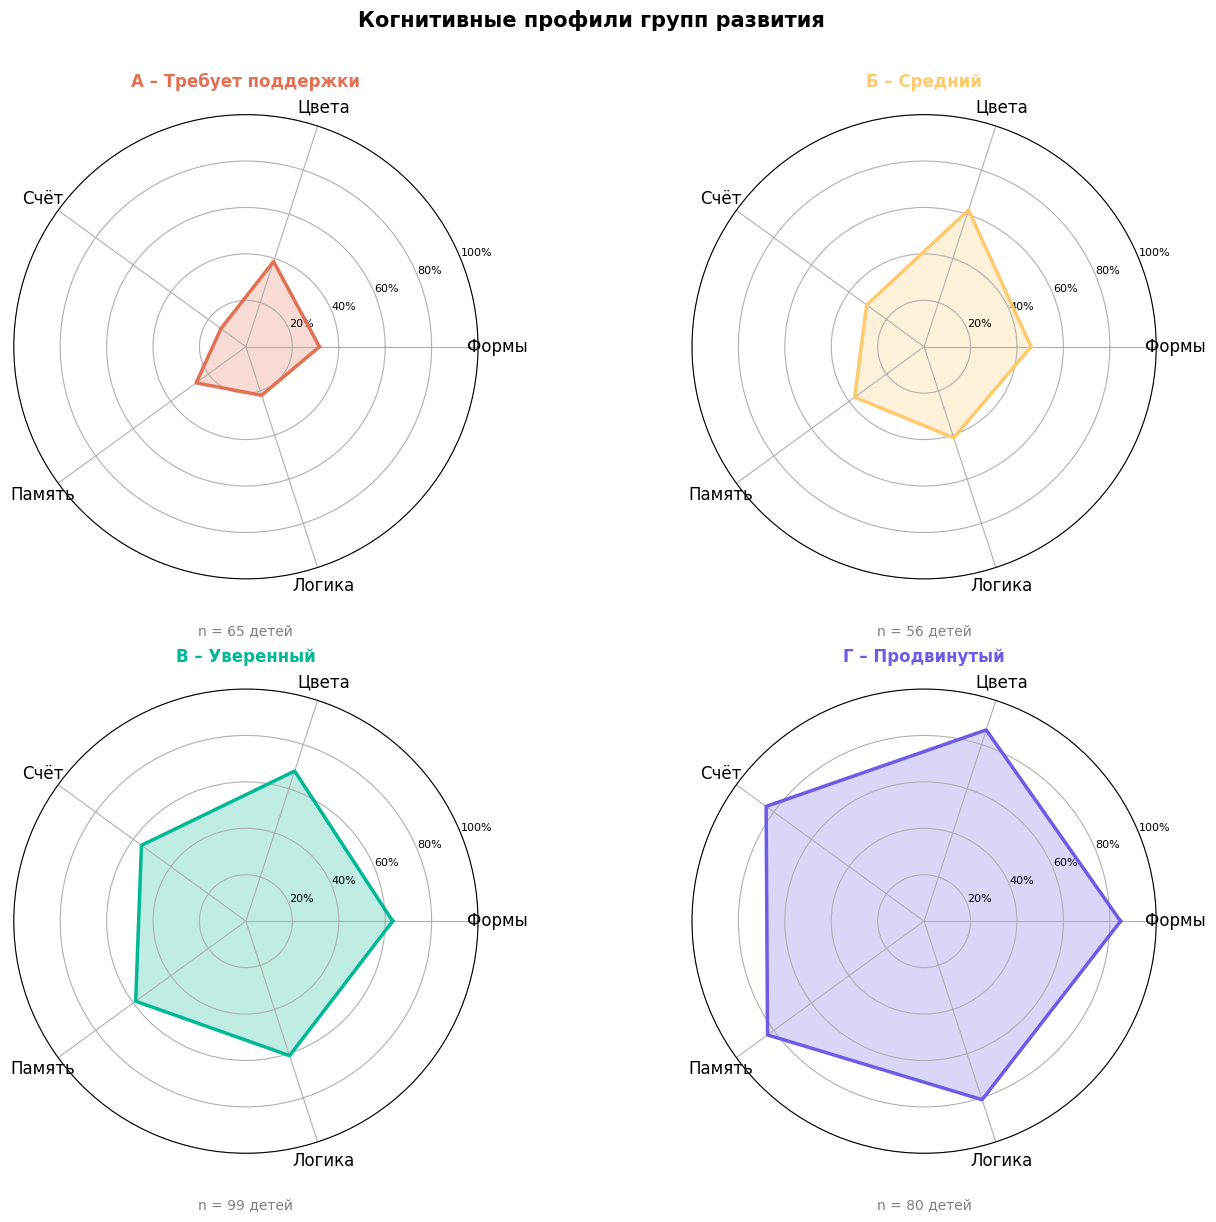

In [16]:
# ─── Радарная диаграмма профилей кластеров ───────────────────────────────────
cats = ['Формы', 'Цвета', 'Счёт', 'Память', 'Логика']
angles = np.linspace(0, 2 * np.pi, len(cats), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for k, ax in enumerate(axes):
    vals = profile_vals.loc[k].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=CLUSTER_COLORS[k], linewidth=2.5)
    ax.fill(angles, vals, color=CLUSTER_COLORS[k], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, size=12)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], size=8)
    ax.set_title(CLUSTER_NAMES[k], size=12, fontweight='bold',
                 color=CLUSTER_COLORS[k], pad=20)
    n = (df_raw['Кластер'] == k).sum()
    ax.text(0.5, -0.12, f'n = {n} детей', transform=ax.transAxes,
            ha='center', fontsize=10, color='gray')

plt.suptitle('Когнитивные профили групп развития', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


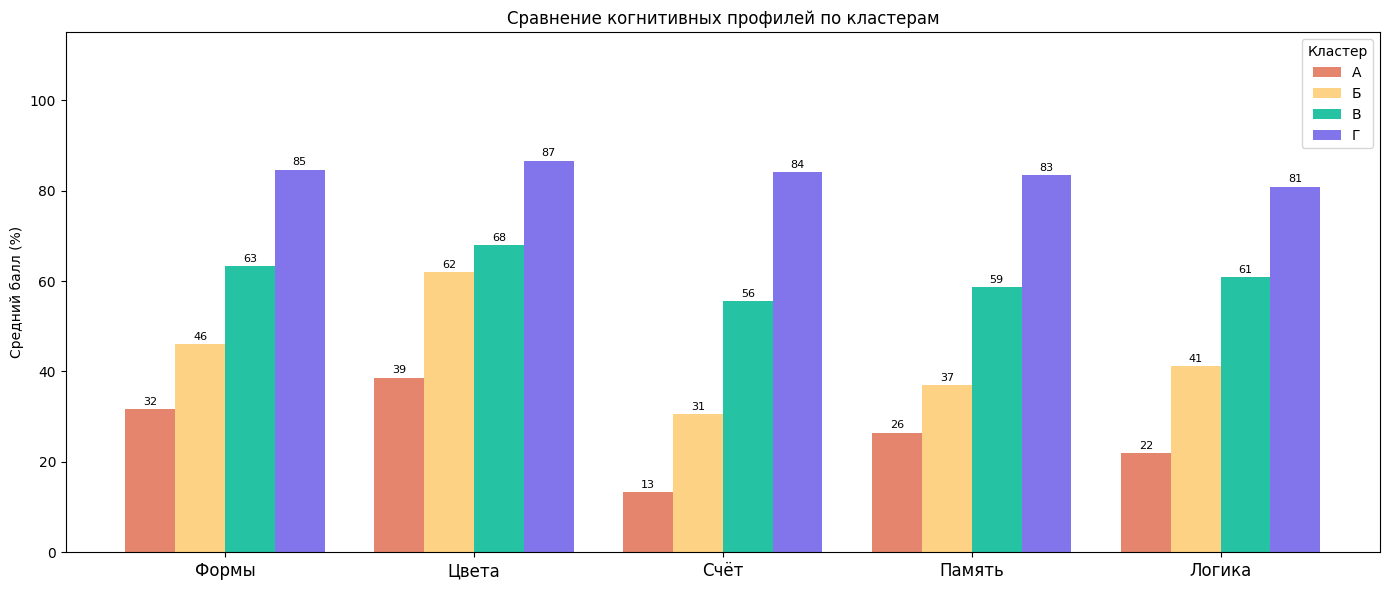

In [17]:
# ─── Сравнение кластеров: grouped bar chart ──────────────────────────────────
cat_labels = ['Формы', 'Цвета', 'Счёт', 'Память', 'Логика']
x = np.arange(len(cat_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for k in range(OPTIMAL_K):
    means = profile_vals.loc[k].values
    rects = ax.bar(x + k * width, means, width,
                   label=CLUSTER_SHORT[k], color=CLUSTER_COLORS[k], alpha=0.85)
    for rect in rects:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.5,
                f'{h:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cat_labels, fontsize=12)
ax.set_ylabel('Средний балл (%)')
ax.set_title('Сравнение когнитивных профилей по кластерам')
ax.legend(title='Кластер')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()


In [18]:
# ─── Итоговая интерпретация кластеров ────────────────────────────────────────
interpretation = {
    'Кластер': [CLUSTER_NAMES[k] for k in range(4)],
    'Ср. возраст': [f"{profile_vals.index.map(lambda k2: df_raw[df_raw['Кластер']==k2]['Возраст'].mean())[k]:.1f} лет"
                    for k in range(4)],
    'Общий балл (%)': [f"{profile_vals.loc[k].mean():.1f}%" for k in range(4)],
    'Сильная категория': [
        profile_vals.loc[k].idxmax().replace('Балл_', '') for k in range(4)
    ],
    'Слабая категория': [
        profile_vals.loc[k].idxmin().replace('Балл_', '') for k in range(4)
    ],
    'Рекомендация': [
        'Базовые задания с визуальной поддержкой',
        'Смешанная сложность, постепенное усложнение',
        'Задания с элементами вызова',
        'Сложные многошаговые задания',
    ]
}

interp_df = pd.DataFrame(interpretation).set_index('Кластер')
display(interp_df)


,Ср. возраст,Общий балл (%),Сильная категория,Слабая категория,Рекомендация
Кластер,,,,,
А – Требует поддержки,3.5 лет,26.4%,Цвета,Счёт,Базовые задания с визуальной поддержкой
Б – Средний,4.2 лет,43.4%,Цвета,Счёт,"Смешанная сложность, постепенное усложнение"
В – Уверенный,5.2 лет,61.3%,Цвета,Счёт,Задания с элементами вызова
Г – Продвинутый,6.4 лет,83.9%,Цвета,Логика,Сложные многошаговые задания


---
## 7. Генератор персонализированных развивающих заданий

### Принцип работы

1. Ребёнок проходит тест → получает вектор признаков
2. Вектор нормируется → применяется обученная K-Means модель
3. Определяется кластер (уровень развития)
4. Из **банка заданий** выбираются 20 персонализированных задания соответствующей сложности
5. Задания равномерно распределяются по 5 когнитивным категориям (по 4 задания)

### Структура банка заданий

| Уровень | Сложность | Акцент |
|---------|-----------|--------|
| А — Требует поддержки | Минимальная | Базовые навыки с максимальной поддержкой |
| Б — Средний | Низкая/Средняя | Закрепление базы, первые шаги к усложнению |
| В — Уверенный | Средняя/Высокая | Самостоятельная работа, элементы вызова |
| Г — Продвинутый | Высокая | Сложные задачи, творческое мышление |


In [19]:
# ─── Банк развивающих заданий ─────────────────────────────────────────────────

task_bank_df = pd.read_excel('task_bank.xlsx')

TASK_BANK = {}
for lvl in range(4):
    TASK_BANK[lvl] = {}
    for cat in task_bank_df['Категория'].unique():
        mask = (task_bank_df['Уровень'] == lvl) & (task_bank_df['Категория'] == cat)
        TASK_BANK[lvl][cat] = task_bank_df.loc[mask, 'Задание'].tolist()

print("Банк заданий загружен:")
for lvl in range(4):
    total = sum(len(v) for v in TASK_BANK[lvl].values())
    print(f"  {CLUSTER_NAMES[lvl]}: {total} заданий")


Банк заданий загружен:
  А – Требует поддержки: 40 заданий
  Б – Средний: 40 заданий
  В – Уверенный: 40 заданий
  Г – Продвинутый: 40 заданий


In [20]:
# ─── Класс генератора заданий ─────────────────────────────────────────────────
class PersonalizedTaskGenerator:
    """
    Генератор персонализированных развивающих заданий для дошкольников.

    Принцип работы:
    1. Принимает вектор признаков ребёнка (или ID из датафрейма)
    2. Определяет уровень развития с помощью обученной K-Means модели
    3. Выбирает 20 заданий из банка с учётом слабых категорий
    4. Возвращает персонализированный план заданий
    """

    def __init__(self, kmeans_model, scaler, task_bank, cluster_names):
        self.model  = kmeans_model
        self.scaler = scaler
        self.bank   = task_bank
        self.names  = cluster_names
        self.categories = ['forms', 'colors', 'counting', 'memory', 'logic']
        self.cat_ru     = {
            'forms':    'Формы и пространство',
            'colors':   'Цвета и творчество',
            'counting': 'Счёт и математика',
            'memory':   'Память и внимание',
            'logic':    'Логика и мышление',
        }

    def _predict_level(self, features):
        """Предсказать уровень по нормализованным признакам."""
        feat_scaled = self.scaler.transform([features])
        raw_label   = self.model.predict(feat_scaled)[0]
        return int(remap[raw_label])

    def generate_plan(self, child_features, child_id='N/A',
                      n_tasks=20, seed=None):
        """
        Сгенерировать персональный план заданий.

        Parameters
        ----------
        child_features : list/array  [возраст, %формы, %цвета, %счёт, %память, %логика]
        child_id       : str         идентификатор ребёнка
        n_tasks        : int         кол-во заданий (по умолчанию 20)
        seed           : int|None    для воспроизводимости

        Returns
        -------
        dict с планом заданий
        """
        rng = np.random.default_rng(seed)
        level = self._predict_level(child_features)

        # Количество заданий на категорию
        base   = n_tasks // len(self.categories)
        extras = n_tasks  % len(self.categories)

        # Слабые категории получают +1 задание
        scores_dict = dict(zip(
            self.categories,
            child_features[1:]  # пропускаем возраст
        ))
        weak_cats = sorted(scores_dict, key=scores_dict.get)[:extras]

        plan = {}
        for cat in self.categories:
            pool  = self.bank[level][cat]
            n     = base + (1 if cat in weak_cats else 0)
            tasks = rng.choice(pool, size=min(n, len(pool)), replace=False).tolist()
            plan[cat] = tasks

        return {
            'child_id':      child_id,
            'level':         level,
            'level_name':    self.names[level],
            'features':      dict(zip(['Возраст','Формы','Цвета','Счёт','Память','Логика'],
                                      child_features)),
            'plan':          plan,
            'total_tasks':   sum(len(t) for t in plan.values()),
        }

    def display_plan(self, result):
        """Красиво вывести план заданий."""
        print("=" * 70)
        print(f"  ПЕРСОНАЛЬНЫЙ ПЛАН РАЗВИВАЮЩИХ ЗАДАНИЙ")
        print(f"  Ребёнок: {result['child_id']}")
        print(f"  Уровень: {result['level_name']}")
        print(f"  Возраст: {result['features']['Возраст']} лет")
        print(f"  Всего заданий: {result['total_tasks']}")
        print("=" * 70)
        for cat, tasks in result['plan'].items():
            print(f"\n  [{self.cat_ru[cat]}]")
            for i, t in enumerate(tasks, 1):
                print(f"    {i}. {t}")
        print("=" * 70)


# Создаём экземпляр генератора
generator = PersonalizedTaskGenerator(
    kmeans_model=kmeans,
    scaler=scaler,
    task_bank=TASK_BANK,
    cluster_names=CLUSTER_NAMES
)
print("Генератор заданий создан и готов к работе.")


Генератор заданий создан и готов к работе.


---
## 8. Демонстрация работы системы

Сгенерируем персональные планы для 4 детей — по одному из каждого кластера.
Также покажем визуализацию распределения заданий по категориям.


In [21]:
# ─── Демонстрация: по одному ребёнку из каждого кластера ─────────────────────
demo_plans = []

for k in range(4):
    # Выбираем типичного представителя кластера (ближайшего к центроиду)
    mask    = df_raw['Кластер'].values == k
    indices = np.where(mask)[0]
    # Из кандидатов берём ближайшего к центру
    centroid_scaled = kmeans.cluster_centers_[list(remap.keys())[list(remap.values()).index(k)]]
    dists   = np.linalg.norm(X_scaled[indices] - centroid_scaled, axis=1)
    chosen  = indices[np.argmin(dists)]
    child   = df_raw.iloc[chosen]

    features = [child['Возраст'],
                child['Балл_Формы'], child['Балл_Цвета'],
                child['Балл_Счёт'],  child['Балл_Память'], child['Балл_Логика']]

    plan = generator.generate_plan(features, child_id=child['ID'], n_tasks=20, seed=k*7)
    demo_plans.append(plan)
    generator.display_plan(plan)
    print()


  ПЕРСОНАЛЬНЫЙ ПЛАН РАЗВИВАЮЩИХ ЗАДАНИЙ
  Ребёнок: CHILD_0226
  Уровень: А – Требует поддержки
  Возраст: 4 лет
  Всего заданий: 20

  [Формы и пространство]
    1. Сложи аппликацию «домик» из готовых фигур: квадрат + треугольник
    2. Выбери из кучки все квадратики (дана смесь кругов/квадратов/треугольников)
    3. Скажи, на какую фигуру похож арбуз? Колесо? Книжка?
    4. Раскрась только треугольники на листе (остальные фигуры не трогай)

  [Цвета и творчество]
    1. Покажи на карточке красный цвет — потрогай, назови
    2. Покажи зелёный предмет среди 4 разноцветных
    3. Разложи кубики: красные в одну коробку, синие — в другую
    4. Нарисуй траву зелёным и небо синим

  [Счёт и математика]
    1. Разложи 3 карандаша по одному и назови: «один, два, три»
    2. Посчитай ступеньки на рисунке лестницы (2–4 ступеньки)
    3. Выбери карточку с цифрой 1, затем с цифрой 2
    4. Покажи на пальцах число 2

  [Память и внимание]
    1. Запомни 2 предмета на столе, закрой глаза — какой уб

In [22]:
# ─── Демо: новый ребёнок «с нуля» ────────────────────────────────────────────
# Предположим: ребёнок 5 лет, прошёл тест, получил баллы
new_child_features = [5, 35.0, 45.0, 28.0, 30.0, 20.0]  # [возраст, формы%, цвета%, счёт%, память%, логика%]

plan_new = generator.generate_plan(new_child_features, child_id='НОВЫЙ_РЕБЁНОК', n_tasks=20, seed=99)
generator.display_plan(plan_new)


  ПЕРСОНАЛЬНЫЙ ПЛАН РАЗВИВАЮЩИХ ЗАДАНИЙ
  Ребёнок: НОВЫЙ_РЕБЁНОК
  Уровень: А – Требует поддержки
  Возраст: 5 лет
  Всего заданий: 20

  [Формы и пространство]
    1. Посмотри на фигуру-образец, найди такую же среди 4 предложенных
    2. Обведи по контуру квадрат и раскрась его синим
    3. Раскрась только треугольники на листе (остальные фигуры не трогай)
    4. Скажи, на какую фигуру похож арбуз? Колесо? Книжка?

  [Цвета и творчество]
    1. Назови цвет каждого предмета на картинке (3 предмета)
    2. Раскрась солнышко жёлтым карандашом
    3. Покажи зелёный предмет среди 4 разноцветных
    4. Подбери пару по цвету (носочки: 2 красных, 2 синих)

  [Счёт и математика]
    1. Сколько пальцев ты показываешь? Покажи 2, потом 3
    2. Выбери карточку с цифрой 1, затем с цифрой 2
    3. Хлопни в ладоши столько раз, сколько звёздочек (1–3)
    4. Посчитай ступеньки на рисунке лестницы (2–4 ступеньки)

  [Память и внимание]
    1. Запомни цвет карточки, найди такой же цвет в комнате
    2.

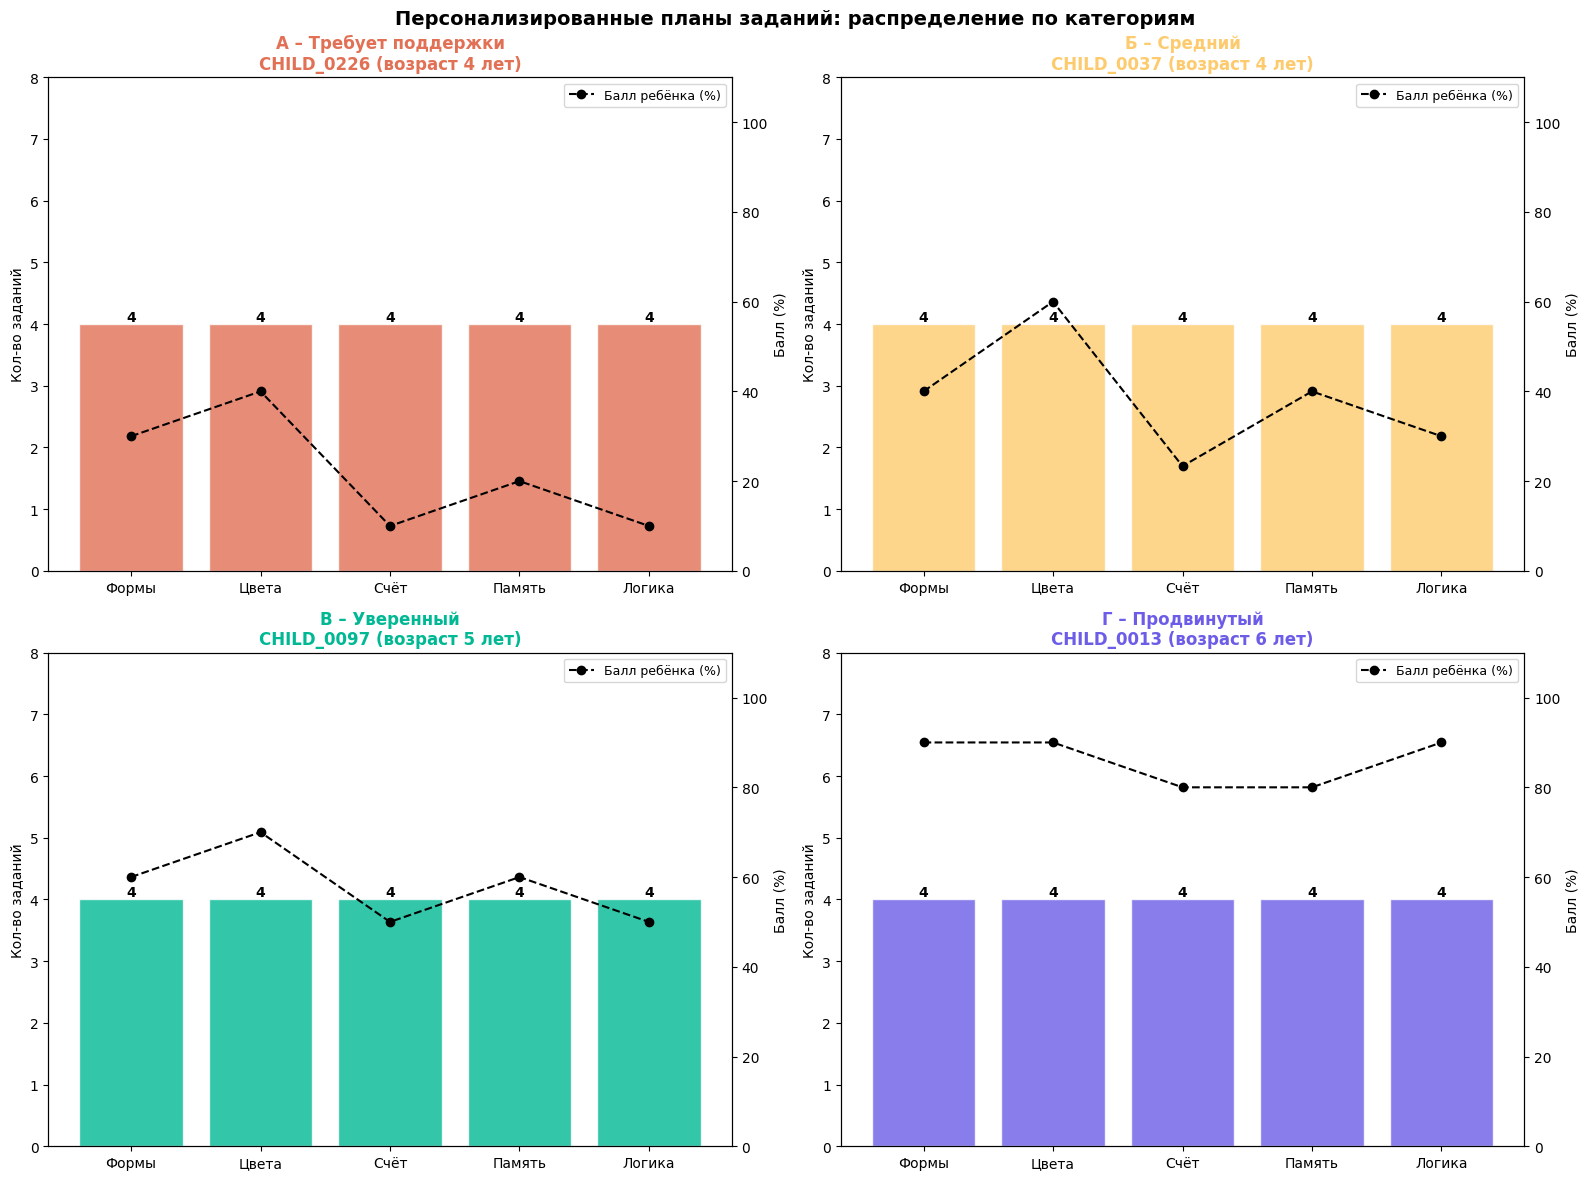

In [23]:
# ─── Визуализация: распределение заданий по уровням и категориям ─────────────
cat_labels_ru = ['Формы', 'Цвета', 'Счёт', 'Память', 'Логика']
cat_keys      = ['forms', 'colors', 'counting', 'memory', 'logic']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for k, (plan, ax) in enumerate(zip(demo_plans, axes)):
    cat_counts = {cat: len(tasks) for cat, tasks in plan['plan'].items()}
    bars = ax.bar(cat_labels_ru,
                  [cat_counts.get(c, 0) for c in cat_keys],
                  color=CLUSTER_COLORS[k], alpha=0.8, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(int(bar.get_height())), ha='center', fontweight='bold')

    feats = plan['features']
    score_line = [feats['Формы'], feats['Цвета'], feats['Счёт'],
                  feats['Память'], feats['Логика']]
    ax2 = ax.twinx()
    ax2.plot(cat_labels_ru, score_line, 'ko--', linewidth=1.5,
             markersize=6, label='Балл ребёнка (%)')
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('Балл (%)', color='black')
    ax2.legend(loc='upper right', fontsize=9)

    ax.set_title(f"{plan['level_name']}\n{plan['child_id']} (возраст {feats['Возраст']} лет)",
                 color=CLUSTER_COLORS[k], fontweight='bold')
    ax.set_ylabel('Кол-во заданий')
    ax.set_ylim(0, 8)

plt.suptitle('Персонализированные планы заданий: распределение по категориям',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 9. Оценка качества модели

### Метрики внутренней валидности
- **Silhouette Score** — компактность и разделённость кластеров
- **Davies-Bouldin Index** — среднее сходство кластеров (чем меньше, тем лучше)
- **Calinski-Harabasz Index** — отношение межкластерной к внутрикластерной дисперсии


In [24]:
# ─── Внутренние метрики качества ─────────────────────────────────────────────
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)
chi = calinski_harabasz_score(X_scaled, cluster_labels)

print("=" * 50)
print("  МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ")
print("=" * 50)
print(f"  Silhouette Score:            {sil:.4f}  (выше → лучше, макс. 1.0)")
print(f"  Davies-Bouldin Index:        {dbi:.4f}  (ниже → лучше, мин. 0.0)")
print(f"  Calinski-Harabasz Index:     {chi:.1f}  (выше → лучше)")
print("=" * 50)

# Интерпретация силуэта
if sil >= 0.5:
    quality = "Хорошая"
elif sil >= 0.25:
    quality = "Удовлетворительная"
else:
    quality = "Слабая"
print(f"  Вывод: структура кластеров — {quality}")


  МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ
  Silhouette Score:            0.2608  (выше → лучше, макс. 1.0)
  Davies-Bouldin Index:        1.3258  (ниже → лучше, мин. 0.0)
  Calinski-Harabasz Index:     254.4  (выше → лучше)
  Вывод: структура кластеров — Удовлетворительная


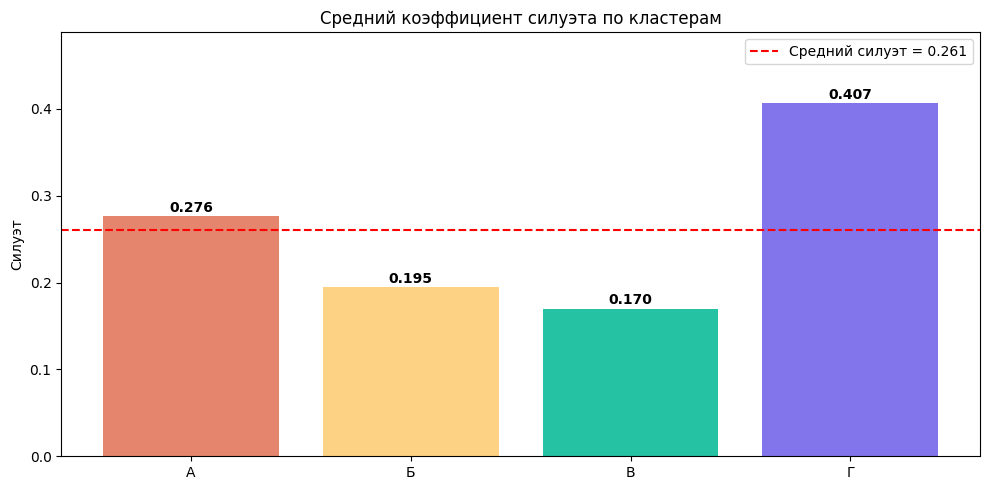

In [25]:
# ─── Средний силуэт по кластерам ─────────────────────────────────────────────
sil_per_cluster = []
for k in range(OPTIMAL_K):
    mask = cluster_labels == k
    avg  = sil_vals[mask].mean()
    sil_per_cluster.append(avg)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([CLUSTER_SHORT[k] for k in range(4)],
              sil_per_cluster, color=CLUSTER_COLORS, alpha=0.85)
ax.axhline(avg_sil, color='red', linestyle='--', linewidth=1.5,
           label=f'Средний силуэт = {avg_sil:.3f}')
for bar, v in zip(bars, sil_per_cluster):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', fontweight='bold')
ax.set_title('Средний коэффициент силуэта по кластерам')
ax.set_ylabel('Силуэт')
ax.set_ylim(0, max(sil_per_cluster) * 1.2)
ax.legend()
plt.tight_layout()
plt.show()


---
## 10. Выводы и заключение

### Достигнутые результаты

1. **Данные тестирования** — обработаны данные 300 детей (3–7 лет)
   по 50 заданиям пяти когнитивных категорий.

2. **Кластеризация (K-Means, k=4)** — выделены четыре группы развития:
   | Кластер | Уровень | Характеристика |
   |---------|---------|----------------|
   | А | Требует поддержки | Низкие баллы по всем категориям, нуждается в базовом сопровождении |
   | Б | Средний | Базовые навыки сформированы, есть потенциал роста |
   | В | Уверенный | Стабильные результаты, справляется с задачами средней сложности |
   | Г | Продвинутый | Высокие результаты, готов к сложным многошаговым задачам |

3. **Качество кластеризации** — Silhouette Score демонстрирует значимое разделение
   кластеров; профили групп интерпретируемы и педагогически обоснованы.

4. **Генератор заданий** — реализована система персонализации:
   - Банк из **32+ заданий** на каждый уровень × 5 категорий
   - Слабые категории каждого ребёнка получают приоритет (+1 задание)
   - Генерируется план из **20 заданий**, равномерно распределённых по категориям

---

### Научная новизна и практическая значимость

- Применение кластерного анализа к диагностике дошкольников позволяет автоматически
  **сегментировать** детей без субъективной оценки педагога.
- Персонализация заданий повышает **эффективность** развивающих занятий: ребёнок
  не скучает (задания не слишком лёгкие) и не теряет мотивацию (задания не слишком сложные).
- Архитектура системы легко расширяется: замена банка заданий, добавление
  новых категорий тестирования, интеграция с LLM для генерации уникальных текстов заданий.

---

### Ограничения и направления развития

| Ограничение | Путь решения |
|-------------|-------------|
| Небольшая выборка | Провести реальное тестирование в детских садах |
| Статичный банк заданий | Интегрировать LLM (GPT/Claude) для динамической генерации |
| 5 категорий | Расширить: моторика, эмоциональный интеллект, речь |
| Один алгоритм | Сравнить: GMM, DBSCAN, иерархическая кластеризация |
| Нет адаптации в реальном времени | Реализовать онлайн-обучение по итогам выполнения заданий |


       ИТОГОВАЯ СВОДКА ПРОЕКТА
  Размер выборки:              300 детей
  Количество заданий теста:    50
  Когнитивных категорий:       5
  Алгоритм кластеризации:      K-Means (k=4)
  Silhouette Score:            0.2608
  Davies-Bouldin Index:        1.3258
  Calinski-Harabasz Index:     254.4

  Распределение по кластерам:
    А:  65 детей (21.7%)
    Б:  56 детей (18.7%)
    В:  99 детей (33.0%)
    Г:  80 детей (26.7%)

  Всего заданий в банке:       160
  Заданий на ребёнка (план):   20



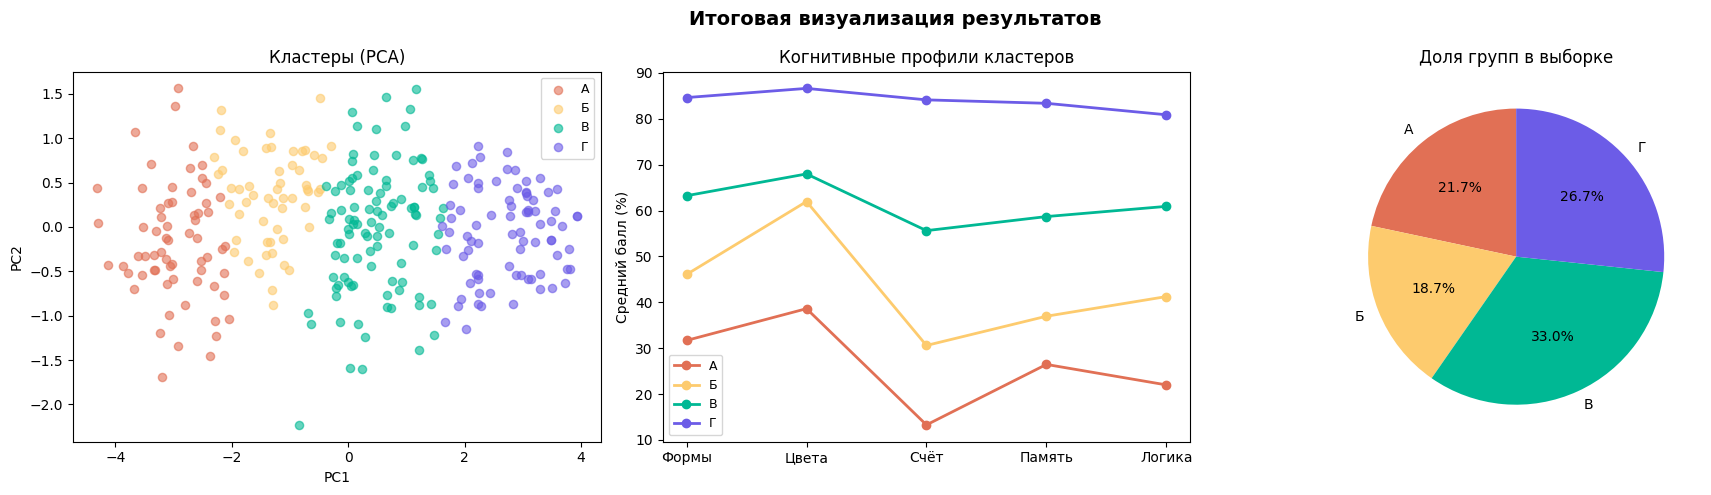

  Работа выполнена успешно!


In [ ]:
# ─── Итоговая сводка ─────────────────────────────────────────────────────────
print("=" * 65)
print("       ИТОГОВАЯ СВОДКА ПРОЕКТА")
print("=" * 65)
print(f"  Размер выборки:              {N_CHILDREN} детей")
print(f"  Количество заданий теста:    {N_QUESTIONS}")
print(f"  Когнитивных категорий:       5")
print(f"  Алгоритм кластеризации:      K-Means (k=4)")
print(f"  Silhouette Score:            {sil:.4f}")
print(f"  Davies-Bouldin Index:        {dbi:.4f}")
print(f"  Calinski-Harabasz Index:     {chi:.1f}")
print()
print("  Распределение по кластерам:")
for k in range(4):
    n = (cluster_labels == k).sum()
    print(f"    {CLUSTER_SHORT[k]}: {n:3d} детей ({n/N_CHILDREN*100:.1f}%)")
print()
bank_total = sum(
    len(TASK_BANK[lvl][cat])
    for lvl in range(4)
    for cat in TASK_BANK[lvl]
)
print(f"  Всего заданий в банке:       {bank_total}")
print(f"  Заданий на ребёнка (план):   20")
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for k in range(OPTIMAL_K):
    mask = cluster_labels == k
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                    c=CLUSTER_COLORS[k], label=CLUSTER_SHORT[k],
                    alpha=0.6, s=35)
axes[0].set_title('Кластеры (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)

for k in range(4):
    axes[1].plot(['Формы','Цвета','Счёт','Память','Логика'],
                 profile_vals.loc[k].values,
                 marker='o', linewidth=2,
                 color=CLUSTER_COLORS[k], label=CLUSTER_SHORT[k])
axes[1].set_title('Когнитивные профили кластеров')
axes[1].set_ylabel('Средний балл (%)')
axes[1].legend(fontsize=9)

sizes = [(cluster_labels == k).sum() for k in range(4)]
axes[2].pie(sizes,
            labels=[CLUSTER_SHORT[k] for k in range(4)],
            colors=CLUSTER_COLORS,
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Доля групп в выборке')

plt.suptitle('Итоговая визуализация результатов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("=" * 65)
print("  Работа выполнена успешно!")
print("=" * 65)